# COWER: 2025 Edition: Runs for Fixed-Bottom & Floating
National Renewable Energy Laboratory\
Daniel Mulas Hernando\
10 October 2025

This notebook allows you to specify the random seeds—and thus control the number of simulations—to run for this particular case. For each simulation, it calculates and saves the availability, OpEx, and vessel cost breakdowns. All results are stored in the `library/base_2024/results` folder for easy access and analysis.

In [1]:
import pandas as pd
from pathlib import Path
from wombat.core import Simulation, Metrics

from wombat.core.library import convert_failure_data

convert_failure_data(configuration="../library/exxon/substations/lbw_substation_50MW-old_format.yaml", which="substation", save_name="../library/exxon/substations/lbw_substation_50MW.yaml", return_dict=False)
convert_failure_data(configuration="../library/exxon/substations/lbw_substation_500MW-old_format.yaml", which="substation", save_name="../library/exxon/substations/lbw_substation_500MW.yaml", return_dict=False)

In [2]:
from pathlib import Path
import pandas as pd
from wombat import Simulation, Metrics  # adjust import if needed

def run_windfarm_simulations(technology: str, random_seeds: list, library_path : str, port_name="base_port_139km"):
    """
    Run simulations for a specified wind farm technology and save
    availability, OpEx, vessel costs, and repair time at port.

    Supported technologies:
      - 'fixed_bottom'
      - 'floating'
    
    Parameters:
    - technology: str, one of the supported technology names
    - random_seeds: list of ints, random seeds for reproducibility
    - port_name: str, name of the port to track repair time

    Saves CSV files in library/exxon/results with appropriate naming.
    """

    # === CONFIGURATION ===
    library_path = Path(library_path).resolve()
    results_dir = library_path / "results"
    results_dir.mkdir(parents=True, exist_ok=True)

    # === CONFIG SELECTION ===
    config_map = {
        "ATB3_3_base": "ATB3_3_base.yaml",
        "ATB3_3_base-case-0": "ATB3_3_base-case-0.yaml",
        "ATB3_3_base-case-1": "ATB3_3_base-case-1.yaml",
        "ATB3_3_base-case-2": "ATB3_3_base-case-2.yaml",
        "ATB3_3_base-case-3": "ATB3_3_base-case-3.yaml",
    }

    # Validate input
    tech_key = technology
    if tech_key not in config_map:
        raise ValueError(
            f"Invalid technology '{technology}'. Must be one of: "
            f"{', '.join(config_map.keys())}"
        )

    config_name = config_map[tech_key]

    # === STORAGE INITIALIZATION ===
    availability_records = []
    opex_records = []
    vessel_records = []
    repair_time_records = []

    # === RUN SIMULATIONS SEQUENTIALLY ===
    for i, seed in enumerate(random_seeds, start=1):
        print(f"🚀 Running simulation {i} ({technology}) with random seed {seed}...")

        # Run simulation
        sim = Simulation(
            library_path=library_path,
            config=config_name,
            random_seed=seed
        )
        sim.run(create_metrics=True, save_metrics_inputs=True)

        # Load metrics
        fpath = sim.env.metrics_input_fname.parent
        fname = sim.env.metrics_input_fname.name
        metrics = Metrics.from_simulation_outputs(fpath, fname)

        # === 1. Availability Results ===
        time_avail = metrics.time_based_availability(frequency="project", by="windfarm")
        prod_avail = metrics.production_based_availability(frequency="project", by="windfarm")
        availability_records.append({
            "run": i,
            "random_seed": seed,
            "time_based_availability": time_avail.iloc[0, 0],
            "production_based_availability": prod_avail.iloc[0, 0],
        })

        # === 2. OpEx Results ===
        opex_df = metrics.opex(frequency="annual", by_category=True).reset_index()
        opex_df.insert(0, "random_seed", seed)
        opex_df.insert(0, "run", i)
        opex_records.append(opex_df)

        # === 3. Vessel Costs ===
        vessel_df = metrics.equipment_costs(frequency="annual", by_equipment=True).reset_index()
        vessel_df.insert(0, "random_seed", seed)
        vessel_df.insert(0, "run", i)
        vessel_records.append(vessel_df)

        # === 4. Repair Time at Port ===
        events_df = sim.env.load_events_log_dataframe()
        events_df['duration'] = pd.to_numeric(events_df['duration'], errors='coerce')
        df_port = events_df[events_df['agent'] == port_name]
        total_hours = df_port['duration'].sum()
        simulation_years = sim.env.end_year - sim.env.start_year + 1
        avg_hours_per_year = total_hours / simulation_years
        avg_days_per_year = avg_hours_per_year / 24
        avg_months_per_year = avg_hours_per_year / (24 * 30.4375)

        repair_time_records.append({
            "run": i,
            "random_seed": seed,
            "avg_repair_time_months": avg_months_per_year,
            "avg_repair_time_days": avg_days_per_year
        })

        # Cleanup logs
        sim.env.cleanup_log_files()

    # === COMBINE AND SAVE RESULTS ===
    df_availability = pd.DataFrame(availability_records)
    df_opex = pd.concat(opex_records, ignore_index=True)
    df_vessels = pd.concat(vessel_records, ignore_index=True)
    df_repair_time = pd.DataFrame(repair_time_records)

    df_availability.to_csv(results_dir / f"COWER-2025-{technology}_all_availability_results.csv", index=False)
    df_opex.to_csv(results_dir / f"COWER-2025-{technology}_all_opex_results.csv", index=False)
    df_vessels.to_csv(results_dir / f"COWER-2025-{technology}_all_vessel_results.csv", index=False)
    df_repair_time.to_csv(results_dir / f"COWER-2025-{technology}_repair_time_at_port_results.csv", index=False)

    print(f"✅ All {technology} simulations complete. Results saved to {results_dir}")


In [3]:
NUM_RUNS = 10

# Run base ATB case
run_windfarm_simulations("ATB3_3_base", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run base ATB case with main bearing added as subassembly - case 0 
run_windfarm_simulations("ATB3_3_base-case-0", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 1
run_windfarm_simulations("ATB3_3_base-case-1", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 2
run_windfarm_simulations("ATB3_3_base-case-2", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

# Run case 3
run_windfarm_simulations("ATB3_3_base-case-3", random_seeds=list(range(1, NUM_RUNS+1)), library_path = "../library/base_2023/")

🚀 Running simulation 1 (ATB3_3_base) with random seed 1...
🚀 Running simulation 2 (ATB3_3_base) with random seed 2...
🚀 Running simulation 3 (ATB3_3_base) with random seed 3...
🚀 Running simulation 4 (ATB3_3_base) with random seed 4...
🚀 Running simulation 5 (ATB3_3_base) with random seed 5...
🚀 Running simulation 6 (ATB3_3_base) with random seed 6...
🚀 Running simulation 7 (ATB3_3_base) with random seed 7...
🚀 Running simulation 8 (ATB3_3_base) with random seed 8...
🚀 Running simulation 9 (ATB3_3_base) with random seed 9...
🚀 Running simulation 10 (ATB3_3_base) with random seed 10...
✅ All ATB3_3_base simulations complete. Results saved to C:\GE-main-bearing\WOMBAT\library\base_2023\results
🚀 Running simulation 1 (ATB3_3_base-case-0) with random seed 1...
🚀 Running simulation 2 (ATB3_3_base-case-0) with random seed 2...
🚀 Running simulation 3 (ATB3_3_base-case-0) with random seed 3...
🚀 Running simulation 4 (ATB3_3_base-case-0) with random seed 4...
🚀 Running simulation 5 (ATB3_3_base

## Summarize Results from Multiple Simulations in One Table

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

def summarize_simulation(library_path="../library/base_2023/results/"):
    """
    Compute average and std results per technology across all simulation runs,
    producing a formatted summary table in $/kW-yr, %, and port repair times.
    """

    # === Project capacities (MW) per technology ===
    project_capacities_mw = {
        "ATB3_3_base": 201.3,
        "ATB3_3_base-case-0": 201.3,
        "ATB3_3_base-case-1": 201.3,
        "ATB3_3_base-case-2": 201.3,
        "ATB3_3_base-case-3": 201.3,
    }

    technologies = list(project_capacities_mw.keys())
    summary_dict = {}

    # Step 1: Collect all vessel columns across all techs
    vessel_cols_all = set()
    for tech in technologies:
        df_vessels = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_vessel_results.csv")
        vessel_cols = [c for c in df_vessels.columns if c not in ["run", "random_seed", "year"]]
        vessel_cols_all.update(vessel_cols)
    vessel_cols_all = sorted(vessel_cols_all)

    # Step 2: Process each technology
    for tech in technologies:
        capacity_kw = project_capacities_mw[tech] * 1_000  # MW → kW

        df_avail = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_availability_results.csv")
        df_opex = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_opex_results.csv")
        df_vessels = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_vessel_results.csv")

        # === Availability ===
        summary_dict.setdefault("avg_time_based_availability", {})[f"{tech} Mean"] = df_avail["time_based_availability"].mean() * 100
        summary_dict["avg_time_based_availability"][f"{tech} Std"] = df_avail["time_based_availability"].std() * 100

        summary_dict.setdefault("avg_production_based_availability", {})[f"{tech} Mean"] = df_avail["production_based_availability"].mean() * 100
        summary_dict["avg_production_based_availability"][f"{tech} Std"] = df_avail["production_based_availability"].std() * 100

        # === OpEx by category ===
        opex_cols = ["operations", "port_fees", "total_labor_cost", "materials_cost"]
        for col in opex_cols:
            if col in df_opex.columns:
                summary_dict.setdefault(col, {})[f"{tech} Mean"] = df_opex[col].mean() / capacity_kw
                summary_dict[col][f"{tech} Std"] = df_opex[col].std() / capacity_kw
            else:
                summary_dict.setdefault(col, {})[f"{tech} Mean"] = np.nan
                summary_dict[col][f"{tech} Std"] = np.nan

        # === Vessel Costs ===
        vessel_total = df_vessels[[c for c in vessel_cols_all if c in df_vessels.columns]].sum(axis=1)
        summary_dict.setdefault("equipment_cost", {})[f"{tech} Mean"] = vessel_total.mean() / capacity_kw
        summary_dict["equipment_cost"][f"{tech} Std"] = vessel_total.std() / capacity_kw

        for col in vessel_cols_all:
            key = f"  - {col}"
            if col in df_vessels.columns:
                summary_dict.setdefault(key, {})[f"{tech} Mean"] = df_vessels[col].mean() / capacity_kw
                summary_dict[key][f"{tech} Std"] = df_vessels[col].std() / capacity_kw
            else:
                summary_dict.setdefault(key, {})[f"{tech} Mean"] = np.nan
                summary_dict[key][f"{tech} Std"] = np.nan

        # === Total OpEx ===
        valid_opex = [col for col in opex_cols if col in df_opex.columns]
        op_ex_total = df_opex[valid_opex].sum(axis=1) + vessel_total
        summary_dict.setdefault("OpEx_total", {})[f"{tech} Mean"] = op_ex_total.mean() / capacity_kw
        summary_dict["OpEx_total"][f"{tech} Std"] = op_ex_total.std() / capacity_kw

    # === Build DataFrame ===
    df_summary = pd.DataFrame(summary_dict).T

    # Row ordering
    avail_rows = ["avg_time_based_availability", "avg_production_based_availability"]
    opex_rows = ["operations", "port_fees", "total_labor_cost", "materials_cost"]
    vessel_rows = ["equipment_cost"] + [f"  - {v}" for v in vessel_cols_all]
    ordered_rows = avail_rows + opex_rows + vessel_rows + ["OpEx_total"]
    df_summary = df_summary.loc[ordered_rows]

    # === Add Project Capacity row ===
    project_capacity_data = {}
    for col in df_summary.columns:
        if "Mean" in col:
            tech_name = col.replace(" Mean", "")
            project_capacity_data[col] = project_capacities_mw.get(tech_name, "-")
        elif "Std" in col:
            project_capacity_data[col] = "-"
        else:
            project_capacity_data[col] = np.nan

    project_capacity_row = pd.DataFrame([project_capacity_data], index=["Project Capacity"])

    # === Add Units column ===
    if "Units" not in df_summary.columns:
        df_summary.insert(0, "Units", np.nan)

    df_summary.loc[:, "Units"] = df_summary.index.map({
        "avg_time_based_availability": "%",
        "avg_production_based_availability": "%",
        "operations": "$ / kW-yr",
        "port_fees": "$ / kW-yr",
        "total_labor_cost": "$ / kW-yr",
        "materials_cost": "$ / kW-yr",
        "equipment_cost": "$ / kW-yr",
        "OpEx Total": "$ / kW-yr",
        "OpEx_total": "$ / kW-yr",
    }).fillna("$ / kW-yr")

    project_capacity_row.insert(0, "Units", "MW")

    # === Combine Project Capacity and main table ===
    df_summary = pd.concat([project_capacity_row, df_summary], axis=0)

    # === Formatting ===
    df_summary.columns = [col.replace("_", " ").title() for col in df_summary.columns]
    df_summary.index = df_summary.index.str.replace("_", " ").str.title()

    # Round all numeric values (mean & std) to 1 decimal
    df_summary = df_summary.applymap(
        lambda x: f"{x:.1f}" if isinstance(x, (int, float, np.number)) and not pd.isna(x) else x
    )

    df_summary.replace(0, np.nan, inplace=True)
    df_summary.fillna("-", inplace=True)

    # Keep Project Capacity even if all other values are "-"
    mean_cols = [c for c in df_summary.columns if "Mean" in c]
    std_cols = [c for c in df_summary.columns if "Std" in c]
    df_summary = df_summary[
        ~((df_summary[mean_cols + std_cols].eq("-").all(axis=1)) & (df_summary.index != "Project Capacity"))
    ]

    return df_summary


In [5]:
summarize_simulation()

C:\Users\dmulash\AppData\Local\Temp\1\ipykernel_28084\1346532861.py:103: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Index(['%', '%', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr',
       '$ / kW-yr', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr',
       '$ / kW-yr', '$ / kW-yr', '$ / kW-yr'],
      dtype='object')' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_summary.loc[:, "Units"] = df_summary.index.map({
C:\Users\dmulash\AppData\Local\Temp\1\ipykernel_28084\1346532861.py:125: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_summary = df_summary.applymap(


,Units,Atb3 3 Base Mean,Atb3 3 Base Std,Atb3 3 Base-Case-0 Mean,Atb3 3 Base-Case-0 Std,Atb3 3 Base-Case-1 Mean,Atb3 3 Base-Case-1 Std,Atb3 3 Base-Case-2 Mean,Atb3 3 Base-Case-2 Std,Atb3 3 Base-Case-3 Mean,Atb3 3 Base-Case-3 Std
Project Capacity,MW,201.3,-,201.3,-,201.3,-,201.3,-,201.3,-
Avg Time Based Availability,%,95.4,0.1,94.9,0.1,95.3,0.1,95.3,0.0,95.3,0.0
Avg Production Based Availability,%,92.2,0.3,92.3,0.1,92.9,0.2,93.1,0.2,93.1,0.3
Operations,$ / kW-yr,25.4,0.0,25.4,0.0,25.4,0.0,25.4,0.0,25.4,0.0
Port Fees,$ / kW-yr,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Total Labor Cost,$ / kW-yr,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Materials Cost,$ / kW-yr,8.8,1.1,10.3,1.9,9.0,1.0,9.1,1.0,9.7,2.6
Equipment Cost,$ / kW-yr,9.0,0.6,9.7,1.3,8.9,0.5,8.9,0.5,9.0,0.6
- Large Crane 1,$ / kW-yr,4.5,1.4,4.4,1.3,4.5,1.2,4.5,1.3,4.5,1.3
- Large Crane 2,$ / kW-yr,4.4,1.3,4.4,1.3,4.3,1.3,4.3,1.3,4.3,1.3


In [6]:
# === CONFIGURATION ===
library_path = Path("../library/base_2023/").resolve()
results_dir = library_path / "results"
summarize_simulation().to_csv(results_dir / f"summary_opex_results_all_cases.csv")

C:\Users\dmulash\AppData\Local\Temp\1\ipykernel_28084\1346532861.py:103: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Index(['%', '%', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr',
       '$ / kW-yr', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr', '$ / kW-yr',
       '$ / kW-yr', '$ / kW-yr', '$ / kW-yr'],
      dtype='object')' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_summary.loc[:, "Units"] = df_summary.index.map({
C:\Users\dmulash\AppData\Local\Temp\1\ipykernel_28084\1346532861.py:125: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_summary = df_summary.applymap(


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

def plot_opex_availability_summary(library_path="../library/base_2023/results/"):
    """
    Create a stacked bar + box plot showing OpEx composition and availability variability
    across simulation cases, avoiding double-counting vessel costs.
    """

    # === Configuration ===
    technologies = [
        "ATB3_3_base",
        "ATB3_3_base-case-0",
        "ATB3_3_base-case-1",
        "ATB3_3_base-case-2",
        "ATB3_3_base-case-3",
    ]
    labels = ["Base", "Case 0", "Case 1", "Case 2", "Case 3"]

    # Professional color palette
    colors = {
        "operations": "#4E79A7",
        "port_fees": "#F28E2B",
        "total_labor_cost": "#E15759",
        "materials_cost": "#76B7B2",
        "equipment_cost": "#59A14F",
    }
    opex_cols = ["operations", "port_fees", "total_labor_cost", "materials_cost"]

    # === Prepare containers ===
    opex_means = {col: [] for col in colors.keys()}
    opex_stds = []
    avail_data = []
    total_opex_runs = []

    # === Loop through technologies ===
    for tech in technologies:
        cap_mw = 201.3
        cap_kw = cap_mw * 1_000

        df_opex = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_opex_results.csv")
        df_vessels = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_vessel_results.csv")
        df_avail = pd.read_csv(Path(library_path) / f"COWER-2025-{tech}_all_availability_results.csv")

        # --- OpEx by category ---
        for col in opex_cols:
            if col in df_opex.columns:
                opex_means[col].append(df_opex[col].mean() / cap_kw)
            else:
                opex_means[col].append(0)

        # --- Vessel total cost (not double counted) ---
        vessel_cols = [c for c in df_vessels.columns if c not in ["run", "random_seed", "year"]]
        vessel_total = df_vessels[vessel_cols].sum(axis=1)
        equipment_mean = vessel_total.mean() / cap_kw
        opex_means["equipment_cost"].append(equipment_mean)

        # --- Total OpEx variability ---
        valid_opex = [col for col in opex_cols if col in df_opex.columns]
        total_opex = df_opex[valid_opex].sum(axis=1) + vessel_total
        total_opex_runs.append(total_opex / cap_kw)
        opex_stds.append(total_opex.std() / cap_kw)

        # --- Availability data ---
        avail_data.append(df_avail["production_based_availability"] * 100)

    # === Plotting ===
    fig, ax1 = plt.subplots(figsize=(10, 6))
    x = np.arange(len(technologies))
    bottom = np.zeros(len(technologies))

    # Remove categories with all zeros
    nonzero_categories = [col for col, vals in opex_means.items() if np.any(np.array(vals) != 0)]

    # --- Stacked bars ---
    for col in nonzero_categories:
        ax1.bar(
            x,
            opex_means[col],
            bottom=bottom,
            label=col.replace("_", " ").title(),
            color=colors[col],
            edgecolor="black",
            linewidth=0.8
        )
        bottom += np.array(opex_means[col])

    # --- Error bars ---
    ax1.errorbar(x, bottom, yerr=opex_stds, fmt='k_', capsize=5, label='Total OpEx Std')

    # --- Text labels (above error bar) ---
    for i, total in enumerate(bottom):
        n_runs = len(total_opex_runs[i])
        upper = total + opex_stds[i]  # top of error bar
        ax1.text(
            x[i],
            upper + 1.5,
            f"{total:.1f}\n(n={n_runs})",
            ha='center',
            va='bottom',
            fontsize=8,
            color='black'
        )

    # === Secondary axis: Availability boxplots ===
    ax2 = ax1.twinx()
    boxprops = dict(facecolor='maroon', alpha=0.3, color='maroon')
    medianprops = dict(color='maroon')
    whiskerprops = dict(color='maroon')
    capprops = dict(color='maroon')

    ax2.boxplot(
        avail_data,
        positions=x,
        widths=0.3,
        patch_artist=True,
        boxprops=boxprops,
        medianprops=medianprops,
        whiskerprops=whiskerprops,
        capprops=capprops
    )

    # --- Add mean availability in red ---
    for i, data in enumerate(avail_data):
        mean_val = data.mean()
        ax2.text(
            x[i] + 0.22, mean_val, f"{mean_val:.1f}%",
            color='red', fontsize=8, va='center', ha='left', fontweight='bold'
        )

    # === Axis formatting ===
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.set_ylabel("OpEx ($/kW-yr)")
    ax2.set_ylabel("Production-Based Availability (%)", color='maroon')
    ax2.tick_params(axis='y', colors='maroon')

    ax1.set_ylim(0, 70)
    ax2.set_ylim(85, 94)

    ax1.set_title("OpEx and Availability Summary by Case")
    ax1.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

    # === Save figure ===
    os.makedirs("Figures", exist_ok=True)
    plt.tight_layout()
    plt.savefig("Figures/OpEx_Availability_Summary.png", dpi=300)
    plt.show()


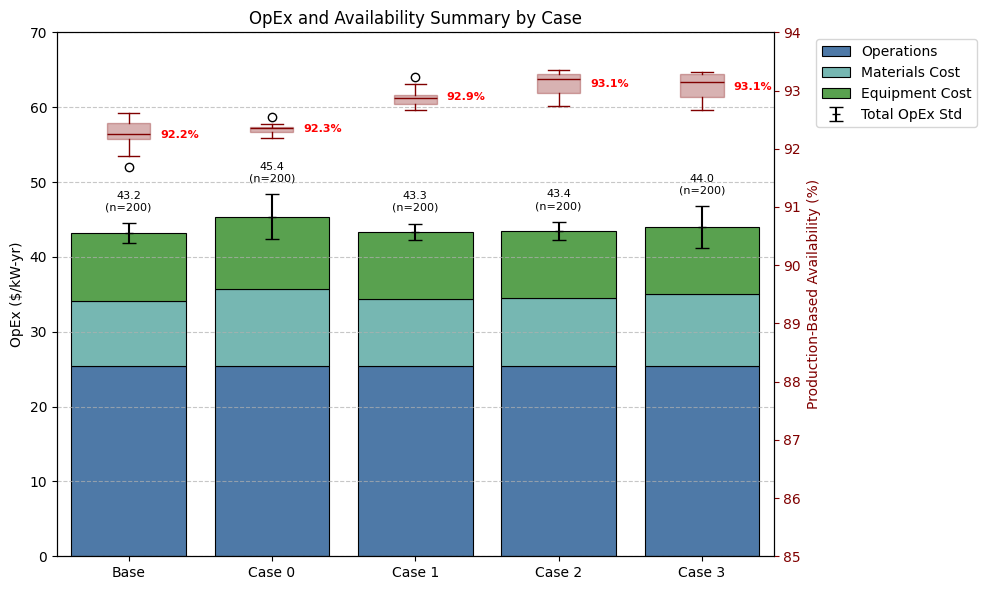

In [21]:
plot_opex_availability_summary()